# Исследование поведения пользователей в MovieLens

## Структура исследования

1. Введение
2. Первичный обзор датасета
4. Разведывательный анализ
5. Анализ ключевых закономерностей
6. Ключевые инсайты
7. Вывод

# 1. Введение

Я всегда испытывал большую любовь к кино и поэтому часто пользуюсь сервисами вроде Letterboxd, где люди ставят оценки фильмам, пишут ревью и делятся отзывами.
После просмотра очередного фильма я заметил одну любопытную вещь: многие **нишевые или авторские фильмы** получают очень высокие оценки, но их оценивает относительно небольшое количество людей.
В то же время **массовые и популярные фильмы** собирают огромное количество оценок, но средний рейтинг у них часто более умеренный.

Возникает вопрос:
это просто субъективное ощущение или за этим действительно стоят закономерности пользовательского поведения?

Чтобы проверить эту гипотезу, я решил провести разведовательный анализ сервиса "MovieLens" - одного из самых известных открытых наборов данных с пользовательскими оценками фильмов.

---

## Исследовательские вопросы

В рамках анализа я постараюсь ответить на несколько вопросов:

1. Как распределены пользовательские оценки?
2. Какие фильмы и жанры получают более высокие рейтинги?
3. Связана ли популярность фильма (число оценок) с его средним рейтингом?
4. Есть ли различия в поведении пользователей по активности и стилю оценивания?

# 2. Первичный обзор датасета

В качестве источника данных используется датасет **"MovieLens"**, содержащий пользовательские оценки фильмов.
Для анализа используются две основные таблицы:

- `movies` - информация о фильмах
- `ratings` - пользовательские оценки фильмов

На данном этапе проводится первичное знакомство с данными: изучается структура таблиц, их размер и типы данных.

In [2]:
#Импорт необходимых библиотек.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid"); # более красивый внешний вид графиков по умолчанию
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
#Импорт данных.
movies = pd.read_csv('C:/Users/Артем/Downloads/archive (1)/movies.csv', sep=',', na_values=[''], quotechar='"')
ratings = pd.read_csv('C:/Users/Артем/Downloads/archive (1)/ratings.csv', sep=',', na_values=[''], quotechar='"')

In [4]:
#Просмотр первых строк таблицы.
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


### Структура таблицы "movies"

Таблица `movies` содержит информацию о фильмах.

Основные поля:
- **movieId** - уникальный идентификатор фильма
- **title** - название фильма (включает год выпуска)
- **genres** - жанры фильма (могут содержать несколько значений)

Жанры записаны в виде строки, где несколько жанров разделены символом `|`.

In [5]:
#Проверяем размеры таблицы.
movies.shape

(9742, 3)

In [6]:
#Методом info() выводим общую информацию о датасете, типы данных, а также есть ли в таблице пропуски.
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [7]:
#Аналогичные действия делаем и со второй таблицей
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


### Структура таблицы "ratings"

Таблица `ratings` содержит пользовательские оценки фильмов.

Основные поля:
- **userId** - идентификатор пользователя
- **movieId** - идентификатор фильма
- **rating** - оценка фильма пользователем
- **timestamp** - время выставления оценки

In [8]:
#Проверяем размеры таблицы.
ratings.shape

(100836, 4)

In [9]:
#Выводим общую информацию о датасете, типы данных, а также есть ли в таблице пропуски.
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [10]:
#Оцениваем количество пользователей, проставивших оценки
ratings["userId"].nunique()

610

In [11]:
#Оцениваем количество фильмов, получивших оценку.
ratings["movieId"].nunique()

9724

In [12]:
# Методом describe() собираем первичную статистику по каждому числовому признаку.
ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


### Первичные наблюдения

На основе базовой статистики можно сделать несколько предварительных наблюдений:

- минимальная оценка фильма - **0.5**
- максимальная оценка - **5**
- медианное значение оценки составляет **3.5**
- стандартное отклонение около **1.04**

Это говорит о том, что распределение оценок может быть относительно широким, однако среднее значение выше середины шкалы.

In [13]:
#Объединяем таблицы
df = ratings.merge(movies, on="movieId")
df

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
...,...,...,...,...,...,...
100831,610,166534,4.0,1493848402,Split (2017),Drama|Horror|Thriller
100832,610,168248,5.0,1493850091,John Wick: Chapter Two (2017),Action|Crime|Thriller
100833,610,168250,5.0,1494273047,Get Out (2017),Horror
100834,610,168252,5.0,1493846352,Logan (2017),Action|Sci-Fi


In [14]:
#Проверяем размер новой таблицы, она должна равняться количеству рейтингов
df.shape

(100836, 6)

# 3. Разведывательный анализ

Прежде чем переходить к более сложным зависимостям, полезно сначала понять базовые характеристики данных.

Одним из ключевых элементов датасета MovieLens являются пользовательские оценки фильмов.
Эти оценки отражают субъективное восприятие фильмов и могут многое рассказать о поведении пользователей.

В онлайн-сервисах с системой рейтингов часто наблюдается интересный эффект: пользователи склонны ставить более высокие оценки, чем низкие.
Это может быть связано с тем, что люди чаще оценивают фильмы, которые им понравились, и реже тратят время на оценку фильмов, которые вызвали негативную реакцию.

Поэтому первым шагом анализа будет проверка того, как именно распределены оценки в датасете.

### Гипотеза:

Пользователи чаще ставят **высокие оценки**, чем низкие.

Если это предположение верно, распределение рейтингов должно быть смещено в сторону значений **4-5**.

Для проверки этой гипотезы необходимо построить распределение рейтингов.

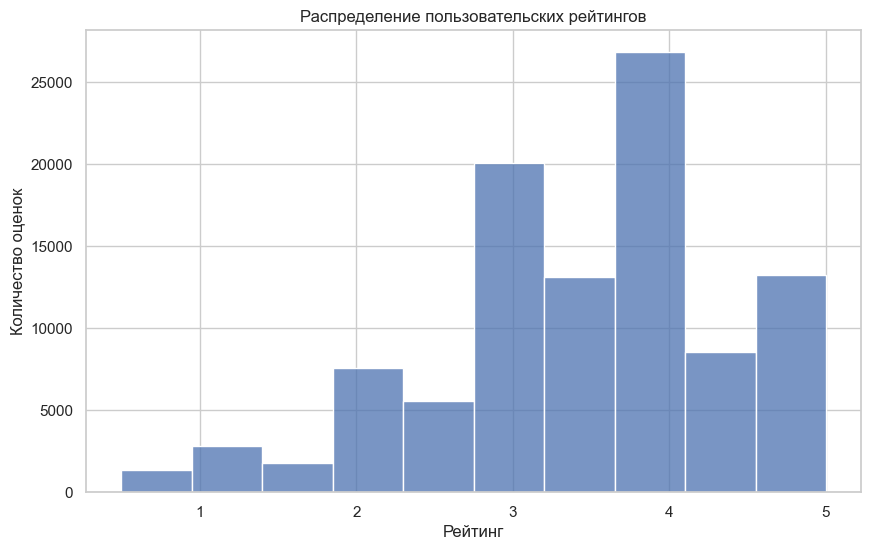

In [15]:
#Строим визуализацию распределения оценок.
sns.histplot(ratings["rating"], bins=10)

plt.title("Распределение пользовательских рейтингов")
plt.xlabel("Рейтинг")
plt.ylabel("Количество оценок")

plt.show()

### Анализ распределения пользовательских рейтингов

Построенная гистограмма показывает, что распределение оценок пользователей смещено в сторону высоких значений.

Наибольшее количество оценок приходится на диапазон **3-5**, при этом пик распределения наблюдается около оценки **4**.

Низкие оценки (0.5-1.5) встречаются значительно реже.
Таким образом, пользователи чаще оставляют оценки фильмам, которые им понравились, и реже оценивают фильмы, вызвавшие негативное впечатление.

Подобное явление часто наблюдается в пользовательских рейтингах и может быть связано и с тем, что пользователи изначально выбирают фильмы, которые с высокой вероятностью им понравятся.

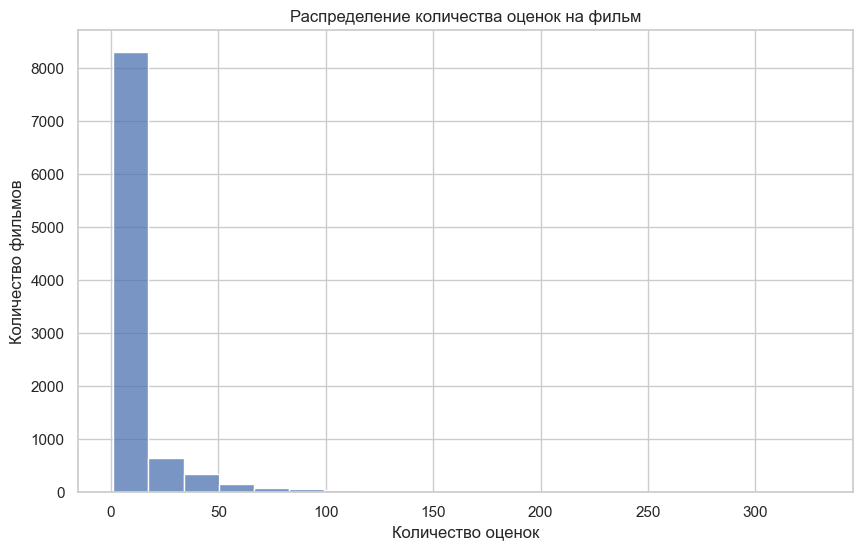

In [16]:
#Теперь построим визуализацию количества отзывов для каждого фильма
ratings_per_movie = ratings.groupby("movieId")["rating"].count()

sns.histplot(ratings_per_movie, bins=20)

plt.title("Распределение количества оценок на фильм")
plt.xlabel("Количество оценок")
plt.ylabel("Количество фильмов")

plt.show()

### Распределение популярности фильмов

Далее был поставлен вопрос: получают ли фильмы одинаковое количество пользовательских оценок?

Для этого было рассчитано количество рейтингов для каждого фильма.

Построенная гистограмма показывает крайне неравномерное распределение популярности.

Большинство фильмов имеет очень небольшое количество оценок, тогда как малая их часть получает значительно больше пользовательских рейтингов.

Таким образом, мы замечаем длинный хвост распределения, когда небольшое число объектов концентрирует основную часть пользовательского внимания, а большая часть объектов получает лишь ограниченное взаимодействие.

Первые серьезные выводы можно сделать такие:
1) Пользователи потребляют очень маленькую часть каталога

2) большинство контента почти не взаимодействует с пользователями

3) Необходимы рекомендательные системы на основе предпочтений пользователей сервиса

## 4. Анализ ключевых закономерностей
Но распределяются ли оценки между фильмами равномерно?

Скорее всего - нет. В любом каталоге фильмов всегда есть небольшое число картин,
которые привлекают основное внимание аудитории. Их активно смотрят, обсуждают и оценивают.

Тогда возникает естественный вопрос: какую долю всех пользовательских оценок получают такие фильмы?

In [17]:
#Смотрим распределения оценок
ratings_per_movie = ratings.groupby('movieId')["rating"].count()
ratings_per_movie.describe()

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: rating, dtype: float64

In [18]:
#Сортируем фильмы по популярности
ratings_sorted = ratings_per_movie.sort_values(ascending=False)
ratings_sorted.head(10)

movieId
356     329
318     317
296     307
593     279
2571    278
260     251
480     238
110     237
589     224
527     220
Name: rating, dtype: int64

## Анализ распределения популярности фильмов

Чтобы понять, как распределяется внимание пользователей, для каждого фильма было рассчитано количество полученных оценок.

Уже на этом этапе становится заметно, что популярность фильмов распределена крайне неравномерно.
Большинство фильмов остаётся практически незамеченным, тогда как небольшая часть собирает значительное число оценок.

Рассмотрим ключевые показатели:

- медианное количество оценок составляет **3**
- 75% фильмов имеют не более **9 оценок**
- максимальное значение достигает **329 оценок**

Эти цифры показывают, насколько сильно смещено распределение.
Фактически половина всех фильмов получает не более трёх оценок - то есть остаётся почти "невидимой" для пользователей.

При этом существует небольшая группа фильмов, которые получают на порядок больше внимания.
Именно они формируют "хвост" распределения и создают сильную асимметрию.

Подобная структура характерна для так называемого **распределения с длинным хвостом**,
где основная часть пользовательского внимания сосредоточена на небольшой доле объектов.

Но насколько сильна эта концентрация на практике?

Какую долю всех оценок получает ограниченное число самых популярных фильмов?

In [19]:
#Считаем кумулятивную сумму оценок по фильмам
cumulative_ratings = ratings_sorted.cumsum()

In [20]:
#Смотрим общее количество оценок
total_ratings = ratings_sorted.sum()

In [21]:
#Доля накопленных оценок
share = cumulative_ratings / total_ratings
share.head(10)

movieId
356     0.003263
318     0.006406
296     0.009451
593     0.012218
2571    0.014975
260     0.017464
480     0.019824
110     0.022175
589     0.024396
527     0.026578
Name: rating, dtype: float64

In [22]:
#Какое количество фильмов собирает 50% всех оценок?
(share <= 0.5).sum()

np.int64(658)

In [23]:
#Какая доля фильмов собирает 50% всех оценок?
(share <= 0.5).sum() / len(share)

np.float64(0.0676676264911559)

In [24]:
#Какое количество фильмов собирает 80% всех оценок?
(share <= 0.8).sum()

np.int64(2224)

In [25]:
#Какая доля фильмов собирает 80% всех оценок?
(share <= 0.8).sum() / len(share)

np.float64(0.22871246400658166)

## Концентрация пользовательского внимания

После того как стало понятно, что популярность фильмов распределена неравномерно, возникает следующий вопрос:
насколько сильно пользовательское внимание сконцентрировано на ограниченном числе фильмов?

Чтобы ответить на него, была рассчитана накопленная доля оценок, приходящаяся на наиболее популярные фильмы.

Результаты оказались довольно показательными:

- **658 фильмов из 9724** аккумулируют **50% всех пользовательских оценок**
- **2224 фильма** аккумулируют **80% всех оценок**

Иными словами:

- всего около **6.8% фильмов** собирают половину всей пользовательской активности
- около **22.9% фильмов** - уже 80% всех оценок

Это означает, что внимание пользователей распределено крайне неравномерно.
Небольшая группа фильмов фактически "забирает" основную часть взаимодействий,
тогда как большая часть каталога остаётся в тени.

Такая структура типична для цифровых платформ с большим объёмом контента.

На практике это выглядит так:
есть небольшой набор популярных фильмов, которые активно смотрят и оценивают,
и есть огромный "длинный хвост" фильмов, которые получают минимальное внимание.

Этот результат напрямую подводит к важному продуктовому выводу:
без рекомендательных систем значительная часть контента остаётся практически невидимой для пользователей.

Именно поэтому алгоритмы рекомендаций играют ключевую роль -
они помогают "вытаскивать" фильмы из длинного хвоста и перераспределять пользовательское внимание внутри платформы.

In [26]:
#Считаем метрики по каждому фильму
movie_stats = ratings.groupby("movieId").agg(
    rating_count=("rating", "count"),
    avg_rating=("rating", "mean")
)
movie_stats

,rating_count,avg_rating
movieId,,
1,215,3.920930
2,110,3.431818
3,52,3.259615
4,7,2.357143
5,49,3.071429
...,...,...
193581,1,4.000000
193583,1,3.500000
193585,1,3.500000


In [27]:
#Объединяем с названиями фильмов
movie_stats = movie_stats.merge(movies, on="movieId")
movie_stats

,movieId,rating_count,avg_rating,title,genres
0,1,215,3.920930,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,110,3.431818,Jumanji (1995),Adventure|Children|Fantasy
2,3,52,3.259615,Grumpier Old Men (1995),Comedy|Romance
3,4,7,2.357143,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,49,3.071429,Father of the Bride Part II (1995),Comedy
...,...,...,...,...,...
9719,193581,1,4.000000,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9720,193583,1,3.500000,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9721,193585,1,3.500000,Flint (2017),Drama
9722,193587,1,3.500000,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


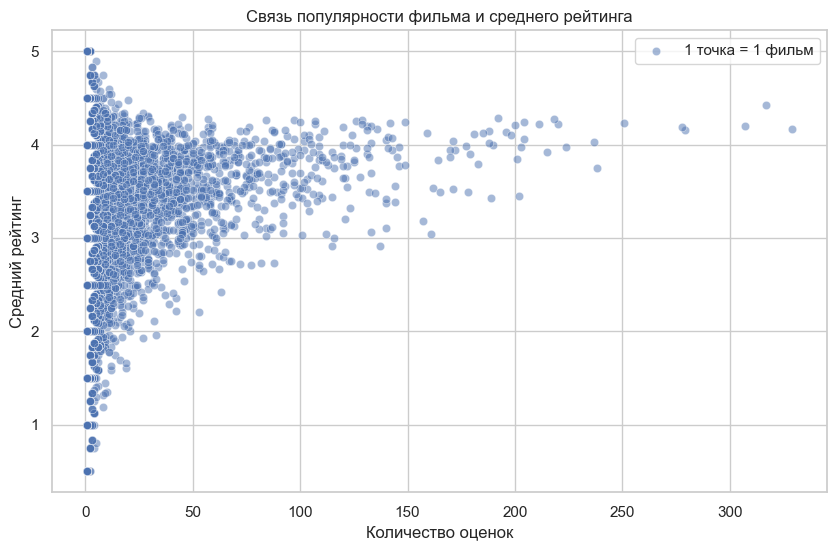

In [68]:
#Строим визуализацию запроса
sns.scatterplot(
    data=movie_stats,
    x="rating_count",
    y="avg_rating",
    alpha=0.5,
    label='1 точка = 1 фильм'
)

plt.title("Связь популярности фильма и среднего рейтинга")
plt.xlabel("Количество оценок")
plt.ylabel("Средний рейтинг")

plt.show()

## Связь популярности фильма и среднего рейтинга

После анализа распределения популярности возникает естественный вопрос:
а связана ли популярность фильма с его оценкой?

Интуитивно можно ожидать, что более популярные фильмы получают более высокие рейтинги.
Однако пользовательское поведение часто оказывается сложнее, чем кажется на первый взгляд.

В рамках анализа:
- популярность фильма измерялась количеством пользовательских оценок
- качество - средним рейтингом

Рассмотрим полученную зависимость.

График показывает несколько характерных особенностей.

**1. Большой разброс оценок у непопулярных фильмов**

Фильмы с небольшим количеством оценок демонстрируют крайне широкий диапазон средних рейтингов - от очень низких до максимальных значений.

Это объясняется тем, что при малом числе наблюдений итоговый рейтинг сильно зависит от отдельных оценок.

**2. Стабилизация рейтинга с ростом популярности**

По мере увеличения числа оценок разброс заметно уменьшается.
Фильмы с большим количеством оценок, как правило, имеют средний рейтинг в диапазоне примерно **3.5–4.3**.

Иными словами, чем больше людей оценили фильм, тем более «стабильной» становится его оценка.

**3. Экстремальные оценки - признак малого числа наблюдений**

Рейтинги, близкие к 5, значительно чаще встречаются у фильмов с небольшим числом оценок.

Таким образом, высокая оценка не всегда означает, что фильм объективно "лучше" -
часто это эффект малого числа голосов.

---

### Вывод

Популярность фильма не гарантирует максимально высокий рейтинг.

Наиболее популярные фильмы, как правило, получают **стабильные, умеренно высокие оценки**,
в то время как менее популярные фильмы могут демонстрировать как очень высокие, так и очень низкие значения рейтинга.

Это важно учитывать при интерпретации пользовательских оценок:
фильмы с малым числом оценок могут давать искажённое представление о качестве.

In [29]:
#Обратим внимание на топ - 10 популярных фильмов
popular_movies = movie_stats[movie_stats["rating_count"] > 100]
popular_movies.sort_values("avg_rating", ascending=False).head(10)

,movieId,rating_count,avg_rating,title,genres
277,318,317,4.429022,"Shawshank Redemption, The (1994)",Crime|Drama
659,858,192,4.289062,"Godfather, The (1972)",Crime|Drama
2224,2959,218,4.272936,Fight Club (1999),Action|Crime|Drama|Thriller
921,1221,129,4.259690,"Godfather: Part II, The (1974)",Crime|Drama
6298,48516,107,4.252336,"Departed, The (2006)",Crime|Drama|Thriller
913,1213,126,4.250000,Goodfellas (1990),Crime|Drama
6693,58559,149,4.238255,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX
46,50,204,4.237745,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
898,1197,142,4.232394,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance
224,260,251,4.231076,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi


## Фильмы с высоким рейтингом и большим количеством оценок

Ранее было показано, что фильмы с небольшим числом оценок могут демонстрировать экстремально высокие рейтинги,
однако такие значения не всегда надёжны.

Поэтому логично ограничить анализ только теми фильмами, которые получили достаточно большое количество оценок.
В данном случае были рассмотрены фильмы с **более чем 100 пользовательскими оценками**.

Это позволяет сосредоточиться на фильмах, чьи рейтинги уже "устоялись" и меньше зависят от случайных факторов.

Среди таких фильмов в топе оказываются хорошо известные и массово признанные картины:

- The Shawshank Redemption
- The Godfather
- Fight Club
- The Dark Knight
- Star Wars

Их средние рейтинги находятся в диапазоне примерно **4.2–4.4**.

На первый взгляд это может показаться неожиданным: даже самые популярные и признанные фильмы
не достигают максимальных оценок.

Однако это хорошо согласуется с ранее обнаруженным эффектом:
при большом числе оценок рейтинг "сглаживается" и становится более устойчивым

В результате получаем:

- популярные фильмы получают **стабильные, но не экстремальные оценки**
- а максимальные значения чаще встречаются у фильмов с малым числом оценок

---

### Вывод

Высокий рейтинг сам по себе ещё не говорит о качестве фильма,
если он основан на небольшом числе оценок.

Для корректного сравнения фильмов необходимо учитывать не только средний рейтинг,
но и количество голосов - иначе можно переоценить нишевые фильмы
и недооценить массово признанные.

Но одинаково ли пользователи оценивают фильмы разных жанров,
или здесь тоже есть свои закономерности?

In [30]:
#Разделяем жанры
movies_genres = movies.copy()
movies_genres["genres"] = movies_genres["genres"].str.split("|")
movies_genres = movies_genres.explode("genres")
movies_genres.head(10)

,movieId,title,genres
0,1,Toy Story (1995),Adventure
0,1,Toy Story (1995),Animation
0,1,Toy Story (1995),Children
0,1,Toy Story (1995),Comedy
0,1,Toy Story (1995),Fantasy
1,2,Jumanji (1995),Adventure
1,2,Jumanji (1995),Children
1,2,Jumanji (1995),Fantasy
2,3,Grumpier Old Men (1995),Comedy
2,3,Grumpier Old Men (1995),Romance


In [31]:
#Присоединяем таблицу с рейтингами
ratings_genres = ratings.merge(movies_genres, on="movieId")
ratings_genres

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure
1,1,1,4.0,964982703,Toy Story (1995),Animation
2,1,1,4.0,964982703,Toy Story (1995),Children
3,1,1,4.0,964982703,Toy Story (1995),Comedy
4,1,1,4.0,964982703,Toy Story (1995),Fantasy
...,...,...,...,...,...,...
274475,610,168252,5.0,1493846352,Logan (2017),Sci-Fi
274476,610,170875,3.0,1493846415,The Fate of the Furious (2017),Action
274477,610,170875,3.0,1493846415,The Fate of the Furious (2017),Crime
274478,610,170875,3.0,1493846415,The Fate of the Furious (2017),Drama


In [32]:
#Средний рейтинг по жанрам
genre_stats = ratings_genres.groupby("genres").agg(
    avg_rating=("rating", "mean"),
    rating_count=("rating", "count")
)
genre_stats.sort_values("avg_rating", ascending=False)

,avg_rating,rating_count
genres,,
Film-Noir,3.920115,870
War,3.808294,4859
Documentary,3.797785,1219
Crime,3.658294,16681
Drama,3.656184,41928
Mystery,3.632460,7674
Animation,3.629937,6988
IMAX,3.618335,4145
Western,3.583938,1930


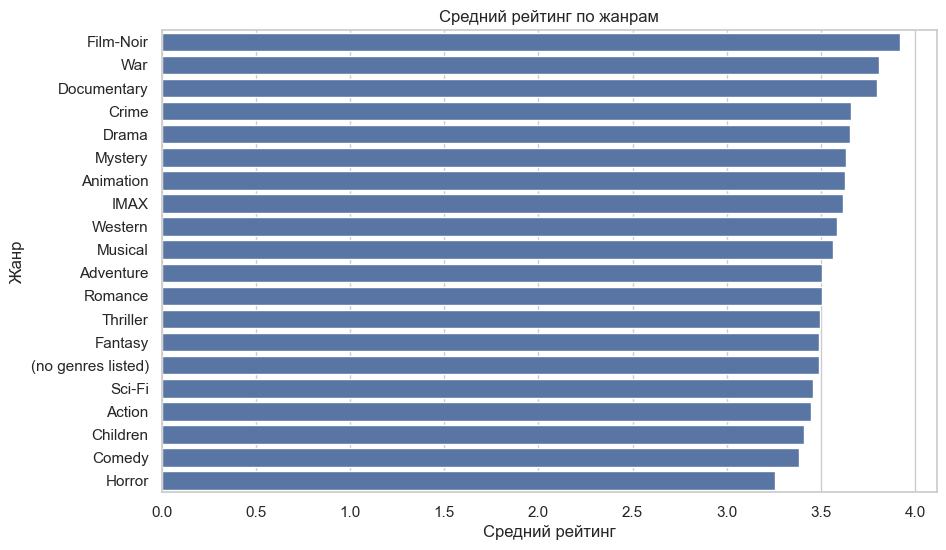

In [33]:
#Визуализация среднего рейтинга по жанрам
sns.barplot(
    data=genre_stats.sort_values("avg_rating", ascending=False),
    x="avg_rating",
    y=genre_stats.sort_values("avg_rating", ascending=False).index
)

plt.title("Средний рейтинг по жанрам")
plt.xlabel("Средний рейтинг")
plt.ylabel("Жанр")

plt.show()

## Анализ пользовательских рейтингов по жанрам

После анализа отдельных фильмов логично посмотреть шире - как пользователи оценивают фильмы в разрезе жанров.

Для этого были рассчитаны средние рейтинги фильмов для каждого жанра. Уже на этом этапе становится заметно, что оценки действительно различаются в зависимости от жанра.

Наиболее высокие средние рейтинги наблюдаются у таких жанров, как "Film-Noir", "War", "Documentary", "Crime" и "Drama". На первый взгляд это может создать впечатление, что именно эти жанры лучше остальных, однако здесь важно учитывать контекст.

Жанры с высокими рейтингами часто имеют относительно небольшую аудиторию. Например, "Film-Noir" демонстрирует один из самых высоких средних рейтингов, но при этом остаётся нишевым жанром с ограниченным числом оценок. Это можно объяснить тем, что такие фильмы чаще смотрят зрители, изначально заинтересованные в подобном контенте, что приводит к более высоким и однородным оценкам.

В противоположность этому, массовые жанры - такие как "Comedy", "Action" и "Horror" - собирают значительно больше оценок, однако их средний рейтинг оказывается несколько ниже. Это связано с более широкой и разнообразной аудиторией, где вкусы и ожидания пользователей существенно различаются, из-за чего оценки становятся более "сглаженными".

Таким образом, жанр действительно влияет на пользовательские оценки, однако этот эффект нельзя интерпретировать напрямую. Более высокие рейтинги часто наблюдаются у нишевых жанров с вовлечённой аудиторией, тогда как массовые жанры демонстрируют более умеренные значения из-за разнообразия пользователей.

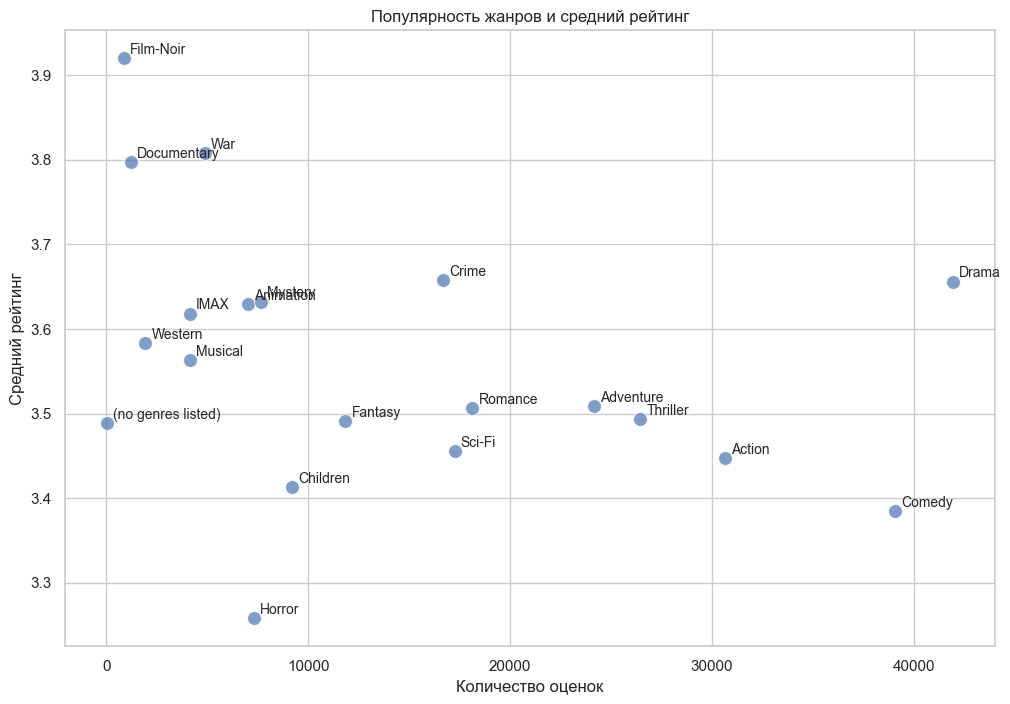

In [34]:
#Визуализация связи популярности жанра и его рейтинга
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=genre_stats,
    x="rating_count",
    y="avg_rating",
    s=100,
    alpha=0.7
)

for genre in genre_stats.index:
    plt.text(
        genre_stats.loc[genre, "rating_count"] + 300,
        genre_stats.loc[genre, "avg_rating"] + 0.005,
        genre,
        fontsize=10
    )

plt.title("Популярность жанров и средний рейтинг")
plt.xlabel("Количество оценок")
plt.ylabel("Средний рейтинг")

plt.show()

## Связь популярности жанра и пользовательского рейтинга

После анализа жанров и популярности фильмов возникает более общий вопрос:
как связаны между собой популярность жанра и его средний рейтинг?

На графике показана зависимость между количеством оценок (как мерой популярности)
и средним рейтингом жанра.

Полученные результаты во многом повторяют уже наблюдавшиеся ранее закономерности.
Жанры с небольшой аудиторией, такие как "Film-Noir", "Documentary" или "War",
как правило, демонстрируют более высокие средние рейтинги, но при этом собирают относительно немного оценок.
Это можно объяснить тем, что такие фильмы чаще смотрят зрители, изначально заинтересованные в подобном контенте,
что приводит к более высоким и однородным оценкам.

В противоположность этому, более массовые жанры - например "Drama", "Comedy" или "Action" -
собирают значительно больше пользовательских оценок, однако их средний рейтинг оказывается немного ниже.
Вероятно, это связано с более широкой и разнообразной аудиторией, где вкусы и ожидания зрителей сильно различаются.

Отдельно можно выделить жанры вроде Horror, которые демонстрируют более низкий средний рейтинг.
Такие фильмы часто вызывают полярную реакцию: они либо очень нравятся зрителям, либо, наоборот, разочаровывают,
что в итоге снижает среднее значение.

Таким образом, популярность жанра и его рейтинг связаны не напрямую.
Более высокие оценки часто наблюдаются у нишевых жанров с вовлечённой аудиторией,
в то время как массовые жанры демонстрируют более умеренные значения из-за разнообразия пользователей.

Но влияет ли время на восприятие фильмов?

Возможно, старые фильмы оцениваются иначе, чем современные:
либо из-за эффекта "классики", либо из-за изменений вкусов аудитории.

Попробуем проверить, меняется ли средний рейтинг фильмов в зависимости от года выпуска.

In [35]:
#Извлекаем год выпуска фильма из названия
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)")
movies["year"] = movies["year"].astype(float)

In [36]:
#Объединение таблиц рейтинга и фильмов.
ratings_movies = ratings.merge(movies, on="movieId")

In [37]:
#Рассчитываем средний рейтинг по годам
ratings_by_year = ratings_movies.groupby("year")["rating"].mean()

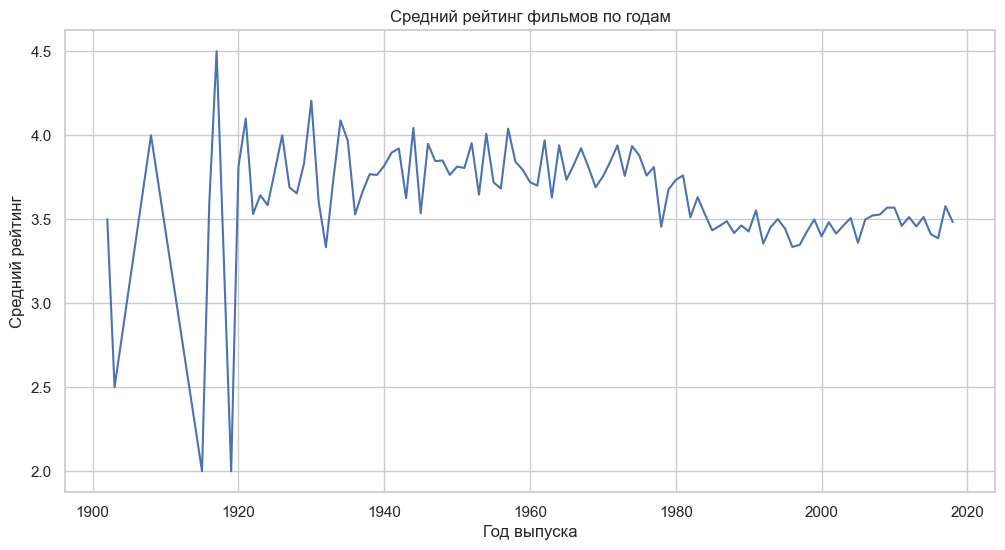

In [38]:
#Визуализация среднего рейтинга по годам
plt.figure(figsize=(12,6))

sns.lineplot(
    x=ratings_by_year.index,
    y=ratings_by_year.values
)

plt.title("Средний рейтинг фильмов по годам")
plt.xlabel("Год выпуска")
plt.ylabel("Средний рейтинг")

plt.show()

## Средний рейтинг фильмов по годам выпуска

На графике показано, как меняется средний пользовательский рейтинг фильмов в зависимости от года выпуска.

В ранние годы (до 1920-х) наблюдается высокая волатильность оценок.
Это связано с тем, что фильмов того периода сохранилось немного, а число оценок ограничено,
из-за чего средние значения оказываются нестабильными.

Начиная примерно с 1930-х и до 1970-х годов средний рейтинг фильмов остаётся на относительно высоком уровне
(около 3.7–3.9). На первый взгляд это может говорить о более высоком качестве кино того времени,
однако здесь важно учитывать эффект отбора.

До наших дней в активном обращении остаются преимущественно наиболее успешные и значимые фильмы прошлого,
в то время как менее удачные работы со временем забываются.
В результате формируется так называемый эффект "выжившего" -
мы наблюдаем только "выжившие" фильмы, что завышает средний рейтинг.

Начиная примерно с 1980-х годов средний рейтинг постепенно снижается и стабилизируется в районе 3.4–3.5.
Это может быть связано с резким увеличением объёма выпускаемого контента и расширением аудитории,
что приводит к большему разнообразию оценок.

Таким образом, более высокие оценки старых фильмов не обязательно означают, что они объективно лучше.
Во многом это отражает особенности отбора контента, который продолжает оцениваться спустя десятилетия.

In [39]:
#Считаем сколько оценок оставляет каждый пользователь
ratings_per_user = ratings.groupby("userId")["rating"].count()

In [40]:
#Смотрим статистику по таблице
ratings_per_user.describe()

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: rating, dtype: float64

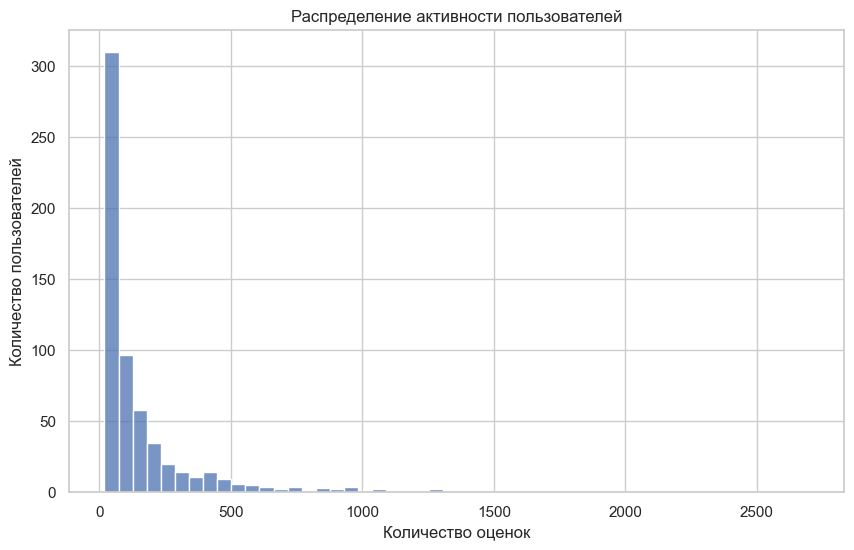

In [41]:
#Визуализируем данное распределение
plt.figure(figsize=(10,6))

sns.histplot(ratings_per_user, bins=50)

plt.title("Распределение активности пользователей")
plt.xlabel("Количество оценок")
plt.ylabel("Количество пользователей")

plt.show()

## Распределение активности пользователей

Помимо анализа фильмов важно понять, как ведут себя сами пользователи -
насколько активно они оставляют оценки.

Для этого было рассмотрено распределение количества оценок на пользователя.

Оказалось, что активность пользователей распределена крайне неравномерно.
Большинство пользователей оставляют относительно небольшое количество оценок,
в то время как небольшая группа демонстрирует очень высокую активность.

Это хорошо видно по ключевым метрикам.
Медианное значение составляет около **70 оценок на пользователя**,
тогда как среднее заметно выше - около **165**.
Такое расхождение указывает на наличие небольшой группы пользователей,
которые оставляют значительно больше оценок, чем остальные.

Максимальные значения достигают почти **2700 оценок**,
что позволяет говорить о существовании группы наиболее активных
пользователей, которые вносят непропорционально большой вклад в формирование данных.

Подобное распределение характерно для многих онлайн-платформ.
Основная часть активности формируется относительно небольшой долей пользователей,
тогда как большинство остаётся умеренно активным.

Этот эффект хорошо согласуется с ранее наблюдавшимся распределением с длинным хвостом:
как и в случае с фильмами, активность концентрируется на небольшой группе объектов -
в данном случае пользователей.

До этого момента мы смотрели на распределение активности пользователей: кто ставит много оценок, кто мало, и как эта активность распределена в целом.

Но сама по себе активность - это только часть картины. Возникает логичный вопрос:
а меняется ли поведение пользователей со временем?

In [42]:
#Прежде чем работать с датами, необходимо перевести соответствующий столбец в необходимый формат.
ratings["date"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings

,userId,movieId,rating,timestamp,date
0,1,1,4.0,964982703,2000-07-30 18:45:03
1,1,3,4.0,964981247,2000-07-30 18:20:47
2,1,6,4.0,964982224,2000-07-30 18:37:04
3,1,47,5.0,964983815,2000-07-30 19:03:35
4,1,50,5.0,964982931,2000-07-30 18:48:51
...,...,...,...,...,...
100831,610,166534,4.0,1493848402,2017-05-03 21:53:22
100832,610,168248,5.0,1493850091,2017-05-03 22:21:31
100833,610,168250,5.0,1494273047,2017-05-08 19:50:47
100834,610,168252,5.0,1493846352,2017-05-03 21:19:12


In [43]:
#Выводим год проставления оценки
ratings["rating_year"] = ratings["date"].dt.year

In [44]:
#Рассчитываем средний рейтинг по годам
ratings_by_year = ratings.groupby("rating_year")["rating"].mean()

In [45]:
#Смотрим общее количество оценок по годам
ratings_count_by_year = ratings.groupby("rating_year")["rating"].count()

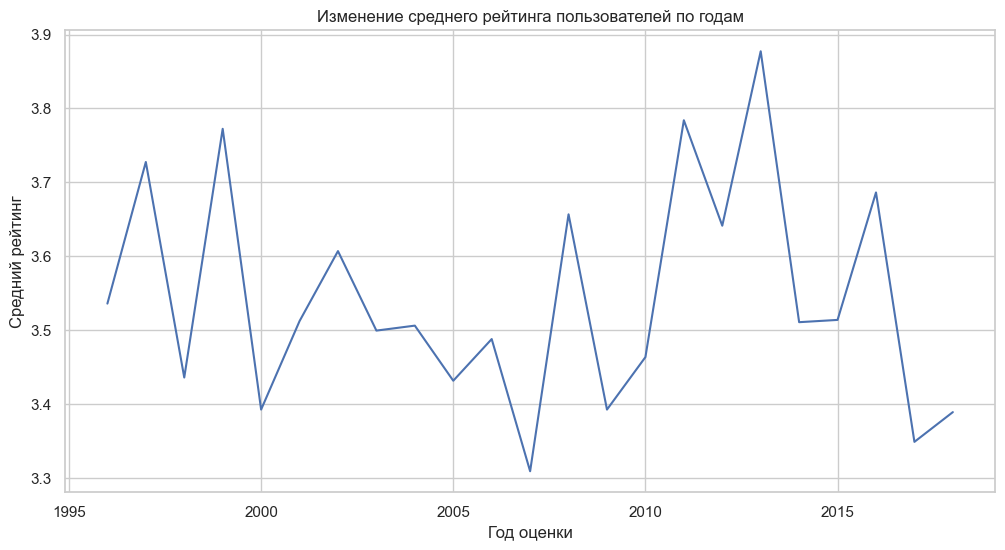

In [46]:
#Визуализируем средний рейтинг пользователей по годам.
plt.figure(figsize=(12,6))

sns.lineplot(
    x=ratings_by_year.index,
    y=ratings_by_year.values
)

plt.title("Изменение среднего рейтинга пользователей по годам")
plt.xlabel("Год оценки")
plt.ylabel("Средний рейтинг")

plt.show()

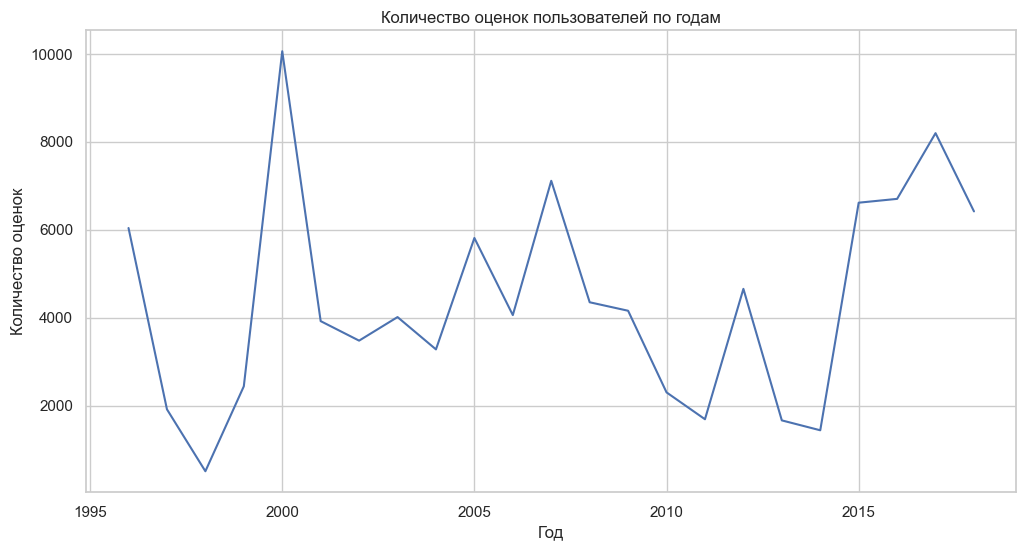

In [47]:
#Визуализация количества оценок по годам.
plt.figure(figsize=(12,6))

sns.lineplot(
    x=ratings_count_by_year.index,
    y=ratings_count_by_year.values
)

plt.title("Количество оценок пользователей по годам")
plt.xlabel("Год")
plt.ylabel("Количество оценок")

plt.show()

## Изменение пользовательских оценок со временем

В завершение анализа имеет смысл посмотреть, как меняются пользовательские оценки во времени.

График среднего рейтинга показывает, что оценки остаются удивительно стабильными на протяжении всего рассматриваемого периода.
Значения колеблются примерно в диапазоне **3.3–3.9**, не демонстрируя выраженного тренда ни к росту, ни к снижению.

Это позволяет предположить, что поведение пользователей в системе оценивания в целом остаётся устойчивым:
со временем пользователи не становятся ни более строгими, ни более щедрыми в своих оценках.

В то же время динамика количества оценок выглядит иначе.
С течением времени наблюдается заметный рост пользовательской активности,
особенно после 2014 года, когда число оценок значительно увеличивается.

Это может быть связано как с ростом популярности платформы,
так и с увеличением числа активных пользователей.

Таким образом, несмотря на рост объёма данных и расширение аудитории,
средний рейтинг фильмов остаётся относительно стабильным.

Это указывает на важную особенность системы:
даже при увеличении количества пользователей и оценок
общая структура распределения оценок сохраняется.

## 6. Ключевые инсайты

В ходе анализа датасета MovieLens были выявлены следующие закономерности в поведении пользователей и структуре оценок:

1. **Пользователи склонны ставить высокие оценки**
   Распределение рейтингов смещено в сторону значений 4–5, что указывает на явный перекос в сторону высоких оценок.

2. **Популярность фильмов распределена крайне неравномерно**
   Большинство фильмов получают очень небольшое количество оценок, тогда как небольшая доля концентрирует основное внимание пользователей.

3. **Небольшая часть фильмов генерирует основную активность**
   Около **6.8% фильмов** собирают **половину** всех оценок, что указывает на выраженное распределение с длинным хвостом.

4. **Популярность не гарантирует высокий рейтинг**
   Наиболее популярные фильмы имеют стабильные, но умеренно высокие оценки (≈3.5–4.3), а экстремальные значения чаще встречаются у малооценённых фильмов.

5. **Рейтинги стабилизируются с ростом числа оценок**
   Чем больше оценок у фильма, тем меньше разброс его среднего рейтинга - эффект сглаживания за счёт увеличения выборки.

6. **Фильмы с малым числом оценок могут вводить в заблуждение**
   Высокие рейтинги у таких фильмов часто являются следствием малого количества наблюдений, а не объективного качества.

7. **Жанры различаются по уровню пользовательских оценок**
   Нишевые жанры, такие как фильмы - нуар, документальные и военные фильмы получают более высокие рейтинги, тогда как более массовые комедии и экшн - фильмы - более умеренные.

8. **Размер аудитории влияет на рейтинг жанра**
   Более широкая аудитория приводит к большему разбросу оценок и снижению среднего значения.

9. **Существует поляризующий эффект отдельных жанров**
   Например, жанр ужасов чаще получает более низкие средние оценки из-за сильной разницы во вкусах пользователей.

10. **Активность пользователей распределена неравномерно**
    Небольшая группа наиболее активных пользователей формирует значительную часть всех оценок, что влияет на агрегированные метрики.

11. **Средний рейтинг остаётся стабильным во времени**
    Несмотря на рост количества оценок и пользователей, средний рейтинг фильмов остаётся в узком диапазоне (≈3.3–3.9).

12. **Старые фильмы имеют завышенные оценки из-за "эффекта отбора"**
    До наших дней доходят преимущественно наиболее успешные фильмы, что создаёт "эффект выжившего".


## 7. Вывод

Пользовательское поведение в системах рейтингов формируется под влиянием нескольких ключевых факторов:
размера аудитории, распределения внимания и объёма данных.

Для корректной интерпретации оценок необходимо учитывать не только средний рейтинг,
но и количество оценок, популярность контента и структуру пользовательской активности.